In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding='latin1')

# Initial inspection
print("Columns in the dataset:", df.columns.tolist())
df.head()

Columns in the dataset: ['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development', 'gender_inequality', 'secondary_education_f_%', 'secondary_education_m_%', 'seats_in_parliament_f_%', 'seats_in_parliament_m_%', 'labour_participation_f_%', 'labour_participation_m_%', 'co2_emission_tons', 'mat_footprint_percap_tons']


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [3]:
# 1. Extract Latest Year (2022)
unique_years = df['year'].unique()
print("Unique years in dataset:", sorted(unique_years))

hdi_2022_df = df[df['year'] == 2022].copy()
print(f"Data for 2022 extracted. Total rows: {len(hdi_2022_df)}")

Unique years in dataset: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Data for 2022 extracted. Total rows: 206


In [4]:
# 2. Data Exploration
print("First 10 rows of the 2022 dataset:")
display(hdi_2022_df.head(10))

print(f"\nNumber of rows and columns: {hdi_2022_df.shape}")
print("\nColumn names and data types:")
print(hdi_2022_df.dtypes)

First 10 rows of the 2022 dataset:


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621



Number of rows and columns: (206, 30)

Column names and data types:
Unnamed: 0                     int64
iso3                          object
country                       object
year                           int64
hdi                          float64
life_expectancy              float64
pop_millions                 float64
hdi_f                        float64
hdi_m                        float64
life_expec_f                 float64
life_expec_m                 float64
expec_yr_school              float64
expec_yr_school_f            float64
expec_yr_school_m            float64
mean_yr_school               float64
mean_yr_school_f             float64
mean_yr_school_m             float64
gross_inc_percap             float64
gross_inc_percap_f           float64
gross_inc_percap_m           float64
gender_development           float64
gender_inequality            float64
secondary_education_f_%      float64
secondary_education_m_%      float64
seats_in_parliament_f_%      float64
seats_

In [5]:
# 3. Missing Values & Data Cleaning
print("Missing values per column:")
print(hdi_2022_df.isnull().sum())

# Check for duplicates
duplicates = hdi_2022_df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Handling missing values: We drop rows where 'hdi' is missing as it's our target metric
hdi_2022_df_cleaned = hdi_2022_df.dropna(subset=['hdi']).copy()

# Replace any special characters like '-' with NaN and then handle them if necessary
hdi_2022_df_cleaned = hdi_2022_df_cleaned.replace('—', np.nan)

print(f"\nData cleaned. Remaining rows: {len(hdi_2022_df_cleaned)}")

Missing values per column:
Unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64


In [6]:
# 4. Basic Statistics
mean_hdi = hdi_2022_df_cleaned['hdi'].mean()
median_hdi = hdi_2022_df_cleaned['hdi'].median()
std_hdi = hdi_2022_df_cleaned['hdi'].std()

print(f"Mean HDI (2022): {mean_hdi:.3f}")
print(f"Median HDI (2022): {median_hdi:.3f}")
print(f"Standard Deviation HDI (2022): {std_hdi:.3f}")

highest_hdi_country = hdi_2022_df_cleaned.loc[hdi_2022_df_cleaned['hdi'].idxmax(), 'country']
lowest_hdi_country = hdi_2022_df_cleaned.loc[hdi_2022_df_cleaned['hdi'].idxmin(), 'country']

print(f"\nCountry with Highest HDI: {highest_hdi_country}")
print(f"Country with Lowest HDI: {lowest_hdi_country}")

Mean HDI (2022): 0.723
Median HDI (2022): 0.740
Standard Deviation HDI (2022): 0.153

Country with Highest HDI: Switzerland
Country with Lowest HDI: Somalia


In [7]:
# 1. Data Extraction (2020-2022)
hdi_problem1B = df[df['year'].isin([2020, 2021, 2022])].copy()
hdi_problem1B.to_csv("HDI_problem1B.csv", index=False)
print("Filtered dataset for 2020-2022 saved as 'HDI_problem1B.csv'.")

Filtered dataset for 2020-2022 saved as 'HDI_problem1B.csv'.


In [8]:
# 2. Data Cleaning for Problem 1B
# Focus on hdi, country, and year
essential_cols = ['hdi', 'country', 'year']
hdi_problem1B_cleaned = hdi_problem1B.dropna(subset=essential_cols).copy()

# Remove potential duplicates
hdi_problem1B_cleaned = hdi_problem1B_cleaned.drop_duplicates()

print(f"Cleaned 1B data. Rows remaining: {len(hdi_problem1B_cleaned)}")

Cleaned 1B data. Rows remaining: 610


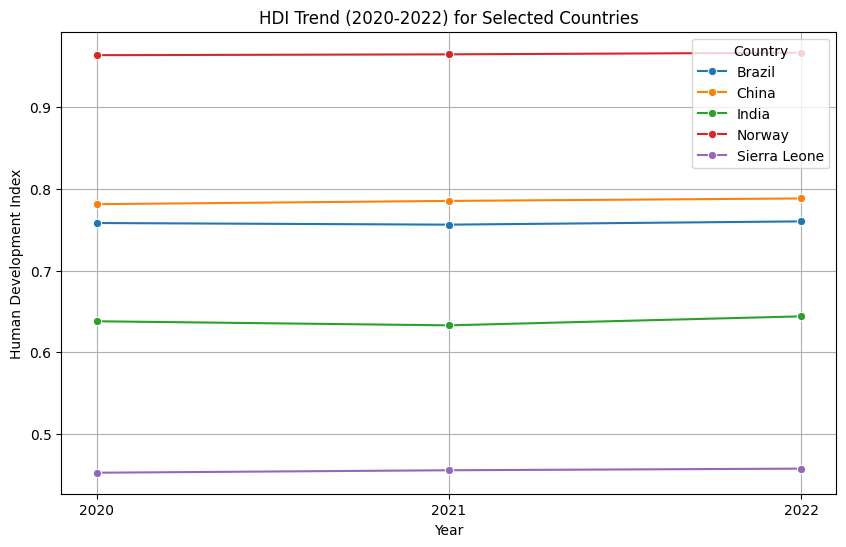

In [9]:
# 3. Visualization: Line Chart
# Selection: Let's pick 5 diverse countries
sample_countries = ["Norway", "India", "Brazil", "China", "Sierra Leone"]
subset_trend = hdi_problem1B_cleaned[hdi_problem1B_cleaned['country'].isin(sample_countries)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=subset_trend, x='year', y='hdi', hue='country', marker='o')
plt.title('HDI Trend (2020-2022) for Selected Countries')
plt.xlabel('Year')
plt.ylabel('Human Development Index')
plt.xticks([2020, 2021, 2022])
plt.grid(True)
plt.legend(title='Country')
plt.savefig('hdi_trend_line_chart.png')
plt.show()

In [10]:
# 1. Create South Asia Subset
south_asian_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]
hdi_south_asia = df[df['country'].isin(south_asian_countries)].copy()

# Use the latest year available for this subset (e.g., 2022)
hdi_sa_latest = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()
hdi_sa_latest.to_csv("HDI_SouthAsia.csv", index=False)
print("South Asia subset saved as 'HDI_SouthAsia.csv'.")

South Asia subset saved as 'HDI_SouthAsia.csv'.


/tmp/ipython-input-3082487903.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_sa, x='Composite Score', y='country', palette='viridis')


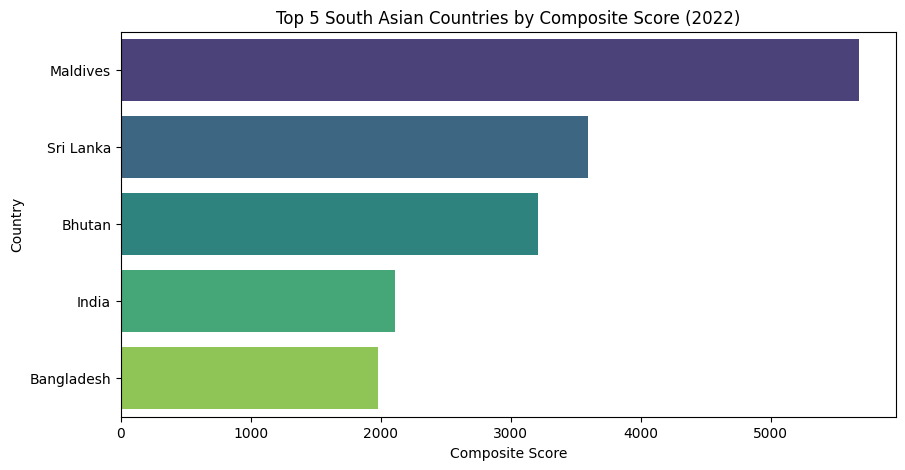

In [11]:
# 2. Composite Development Score
# Formula: 0.30 * Life Expectancy Index + 0.30 * GNI per Capita Index
# We use 'life_expectancy' and 'gross_inc_percap' columns
hdi_sa_latest['Composite Score'] = 0.30 * hdi_sa_latest['life_expectancy'] + 0.30 * hdi_sa_latest['gross_inc_percap']

# Rank and get Top 5
top_5_sa = hdi_sa_latest.sort_values(by='Composite Score', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_5_sa, x='Composite Score', y='country', palette='viridis')
plt.title('Top 5 South Asian Countries by Composite Score (2022)')
plt.xlabel('Composite Score')
plt.ylabel('Country')
plt.savefig('south_asia_composite_score.png')
plt.show()

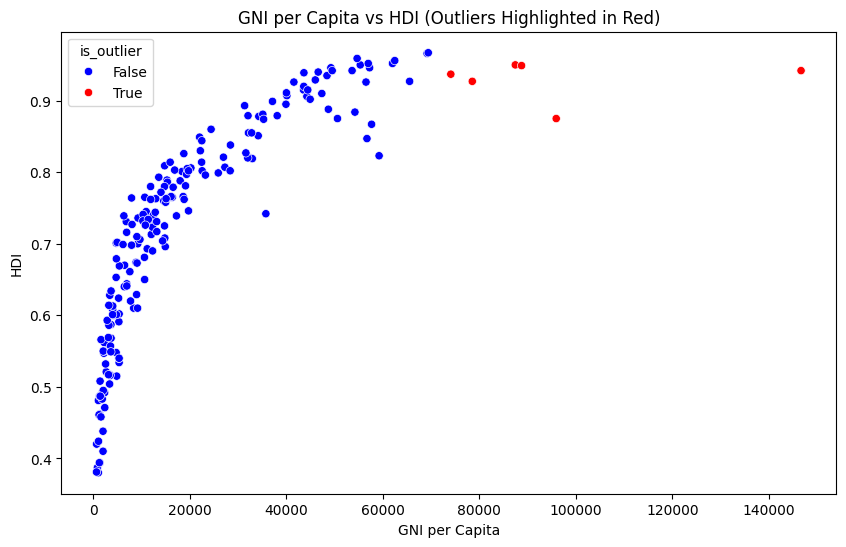

In [12]:
# 3. Outlier Detection
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Detecting on full 2022 cleaned data
hdi_2022_df_cleaned['is_outlier_hdi'] = detect_outliers(hdi_2022_df_cleaned, 'hdi')
hdi_2022_df_cleaned['is_outlier_gni'] = detect_outliers(hdi_2022_df_cleaned, 'gross_inc_percap')
hdi_2022_df_cleaned['is_outlier'] = hdi_2022_df_cleaned['is_outlier_hdi'] | hdi_2022_df_cleaned['is_outlier_gni']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=hdi_2022_df_cleaned, x='gross_inc_percap', y='hdi', hue='is_outlier', palette={True: 'red', False: 'blue'})
plt.title('GNI per Capita vs HDI (Outliers Highlighted in Red)')
plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.savefig('outlier_detection_scatter.png')
plt.show()

Correlation between HDI and gender_development: 0.627


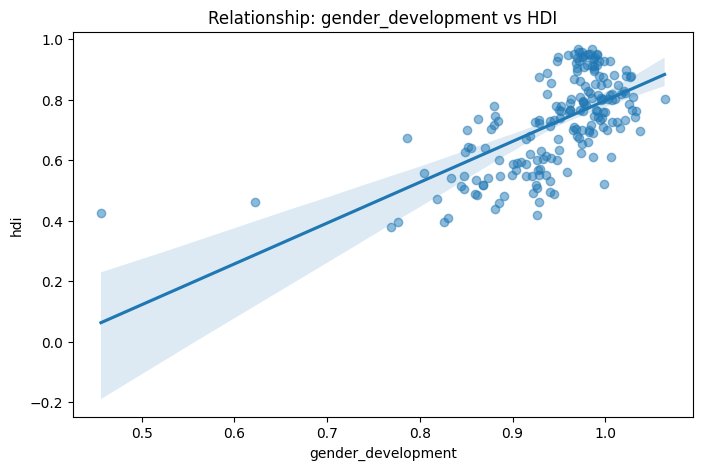

Correlation between HDI and life_expectancy: 0.900


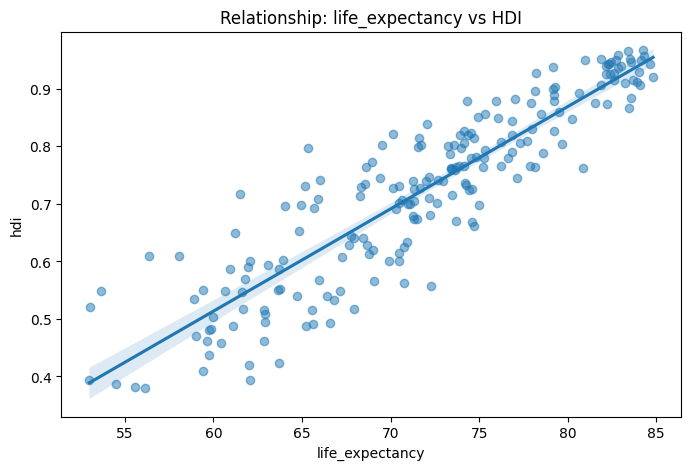

In [13]:
# 4. Metric Relationships
metrics = ['gender_development', 'life_expectancy']
for metric in metrics:
    corr = hdi_2022_df_cleaned['hdi'].corr(hdi_2022_df_cleaned[metric])
    print(f"Correlation between HDI and {metric}: {corr:.3f}")

    plt.figure(figsize=(8, 5))
    sns.regplot(data=hdi_2022_df_cleaned, x=metric, y='hdi', scatter_kws={'alpha':0.5})
    plt.title(f'Relationship: {metric} vs HDI')
    plt.show()

In [14]:
# 1. Create Middle East and South Asia Subsets
middle_east_countries = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon",
                         "Oman", "Palestine", "Qatar", "Saudi Arabia", "Syria",
                         "United Arab Emirates", "Yemen"]

hdi_2020_2022 = pd.read_csv("HDI_problem1B.csv")

hdi_sa_3yr = hdi_2020_2022[hdi_2020_2022['country'].isin(south_asian_countries)]
hdi_me_3yr = hdi_2020_2022[hdi_2020_2022['country'].isin(middle_east_countries)]

hdi_sa_3yr.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
hdi_me_3yr.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)
print("Subsets for South Asia and Middle East saved.")

Subsets for South Asia and Middle East saved.


In [15]:
# 2. Descriptive Statistics (Regional)
print("South Asia HDI Stats:")
print(hdi_sa_3yr.groupby('year')['hdi'].agg(['mean', 'std']))

print("\nMiddle East HDI Stats:")
print(hdi_me_3yr.groupby('year')['hdi'].agg(['mean', 'std']))

mean_sa = hdi_sa_3yr['hdi'].mean()
mean_me = hdi_me_3yr['hdi'].mean()
print(f"\nOverall Mean South Asia: {mean_sa:.3f}")
print(f"Overall Mean Middle East: {mean_me:.3f}")

South Asia HDI Stats:
          mean       std
year                    
2020  0.637625  0.096939
2021  0.638625  0.104200
2022  0.642500  0.107062

Middle East HDI Stats:
          mean       std
year                    
2020  0.787818  0.143401
2021  0.786909  0.145832
2022  0.792000  0.148453

Overall Mean South Asia: 0.640
Overall Mean Middle East: 0.789


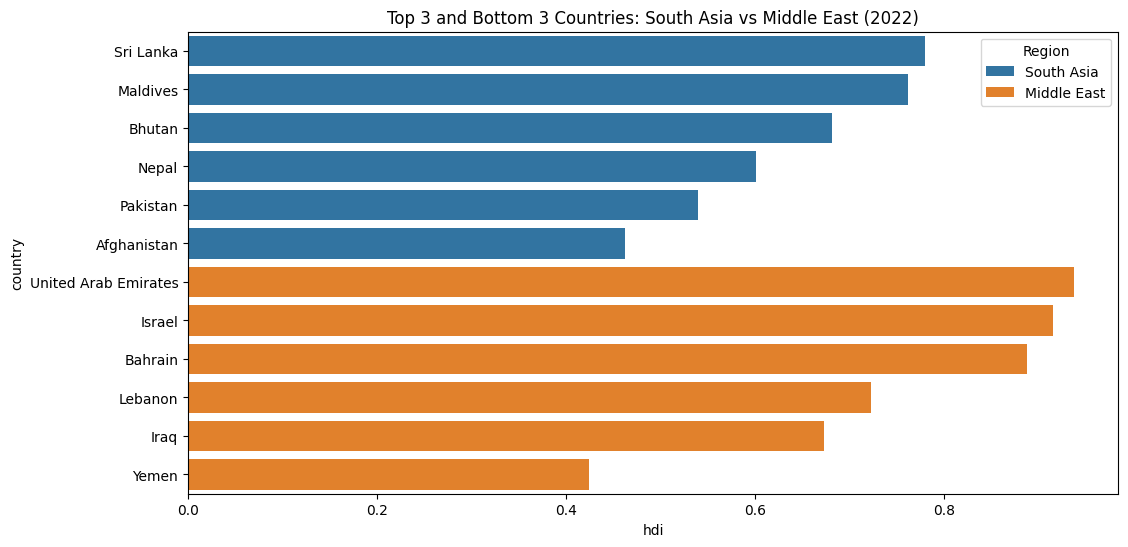

In [16]:
# 3. Top and Bottom Performers
def get_top_bottom(df):
    latest = df[df['year'] == 2022].sort_values(by='hdi', ascending=False)
    return pd.concat([latest.head(3), latest.tail(3)])

tb_sa = get_top_bottom(hdi_sa_3yr)
tb_me = get_top_bottom(hdi_me_3yr)

tb_sa['Region'] = 'South Asia'
tb_me['Region'] = 'Middle East'
combined_tb = pd.concat([tb_sa, tb_me])

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_tb, x='hdi', y='country', hue='Region')
plt.title('Top 3 and Bottom 3 Countries: South Asia vs Middle East (2022)')
plt.show()

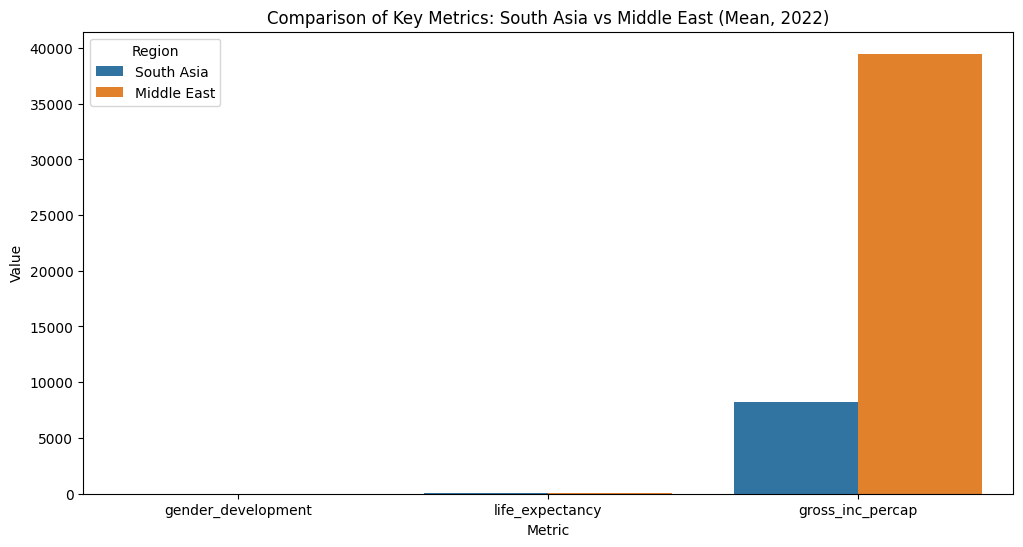

In [17]:
# 4. Metric Comparisons (Grouped Bar Chart)
comp_metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']
hdi_sa_3yr_latest = hdi_sa_3yr[hdi_sa_3yr['year'] == 2022]
hdi_me_3yr_latest = hdi_me_3yr[hdi_me_3yr['year'] == 2022]

summary_data = []
for m in comp_metrics:
    summary_data.append({'Metric': m, 'Region': 'South Asia', 'Value': hdi_sa_3yr_latest[m].mean()})
    summary_data.append({'Metric': m, 'Region': 'Middle East', 'Value': hdi_me_3yr_latest[m].mean()})

summary_df = pd.DataFrame(summary_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='Metric', y='Value', hue='Region')
plt.title('Comparison of Key Metrics: South Asia vs Middle East (Mean, 2022)')
plt.show()

In [18]:
# 5. HDI Disparity
def compute_disparity(df, name):
    latest = df[df['year'] == 2022]['hdi'].dropna()
    hdi_range = latest.max() - latest.min()
    cv = latest.std() / latest.mean()
    print(f"{name} - Range: {hdi_range:.3f}, CV: {cv:.3f}")

compute_disparity(hdi_sa_3yr, "South Asia")
compute_disparity(hdi_me_3yr, "Middle East")

South Asia - Range: 0.318, CV: 0.167
Middle East - Range: 0.513, CV: 0.187
